In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os


In [22]:
def create_arabic_braille_cnn_model(input_shape=(50, 50, 1), num_classes=None):
    model = models.Sequential([
        layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.01),
        layers.Dropout(0.5),
        layers.Dense(512),
        layers.LeakyReLU(alpha=0.01),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model


In [24]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [16]:
!unzip /content/drive/MyDrive/Thesis/Datasets/output.zip -d /content/drive/MyDrive/Thesis/Datasets/FinalDataset

Streaming output truncated to the last 5000 lines.
         continuing with "central" filename version
 extracting: /content/drive/MyDrive/Thesis/Datasets/FinalDataset/output/train/ض/ض (10)_jitterColorHSV.png  
output/train/ض/ض (10)_scale1.png:  mismatching "local" filename (output/train/╪╢/╪╢ (10)_scale1.png),
         continuing with "central" filename version
 extracting: /content/drive/MyDrive/Thesis/Datasets/FinalDataset/output/train/ض/ض (10)_scale1.png  
output/train/ض/ض (10)_scale2.png:  mismatching "local" filename (output/train/╪╢/╪╢ (10)_scale2.png),
         continuing with "central" filename version
 extracting: /content/drive/MyDrive/Thesis/Datasets/FinalDataset/output/train/ض/ض (10)_scale2.png  
output/train/ض/ض (10)_shear_im2.png:  mismatching "local" filename (output/train/╪╢/╪╢ (10)_shear_im2.png),
         continuing with "central" filename version
 extracting: /content/drive/MyDrive/Thesis/Datasets/FinalDataset/output/train/ض/ض (10)_shear_im2.png  
output/train/ض/ض (

In [25]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Thesis/Datasets/FinalDataset/output/train',
    target_size=(50, 50),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Thesis/Datasets/FinalDataset/output/validation',
    target_size=(50, 50),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Thesis/Datasets/FinalDataset/output/test',
    target_size=(50, 50),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)


Found 3555 images belonging to 45 classes.
Found 405 images belonging to 45 classes.
Found 495 images belonging to 45 classes.


In [26]:
print("\nArabic Braille Mapping (Character → Index):")
for char, idx in train_generator.class_indices.items():
    print(f"{idx}: {char}")



Arabic Braille Mapping (Character → Index):
0: damma
1: dammatan
2: fatha
3: fathatan
4: kasra
5: kasratan
6: shadda
7: sukun
8: ء
9: ا
10: آ
11: أ
12: إ
13: ب
14: ة
15: ت
16: ث
17: ج
18: ح
19: خ
20: د
21: ذ
22: ر
23: ز
24: س
25: ش
26: ص
27: ض
28: ط
29: ظ
30: ع
31: غ
32: ف
33: ق
34: ك
35: ل
36: لا
37: م
38: ن
39: ه
40: و
41: ؤ
42: ى
43: ي
44: ئ


In [29]:
num_classes = train_generator.num_classes
model = create_arabic_braille_cnn_model(num_classes=num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [30]:


# Early stopping: stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,             # wait 20 epochs before stopping
    restore_best_weights=True
)

# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # reduce learning rate by 50%
    patience=10,             # wait 10 epochs before reducing
    min_lr=1e-6,             # don't go below this learning rate
    verbose=1
)

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=200,              # max epochs
    callbacks=[early_stopping, reduce_lr]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.0218 - loss: 3.8247 - val_accuracy: 0.0247 - val_loss: 3.7964 - learning_rate: 0.0010
Epoch 2/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 128ms/step - accuracy: 0.0302 - loss: 3.7631 - val_accuracy: 0.0815 - val_loss: 3.4152 - learning_rate: 0.0010
Epoch 3/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - accuracy: 0.1096 - loss: 3.3151 - val_accuracy: 0.5160 - val_loss: 1.8966 - learning_rate: 0.0010
Epoch 4/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 130ms/step - accuracy: 0.3711 - loss: 2.2729 - val_accuracy: 0.7309 - val_loss: 1.0515 - learning_rate: 0.0010
Epoch 5/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.5156 - loss: 1.6861 - val_accuracy: 0.7852 - val_loss: 0.9613 - learning_rate: 0.0010
Epoch 6/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 132ms/step - accuracy: 0.5972 - loss: 1.4132 - val_accuracy: 0.8420 - val_loss: 0.6388 - learning_rate: 0.0010
Epoch 7/200
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step - accura

In [31]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_accuracy:.2f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.9633 - loss: 0.0977

Test Accuracy: 0.96


In [32]:
model.save('/content/drive/MyDrive/Thesis/Models/CNN.h5')
print("\nModel saved successfully!")



Model saved successfully!


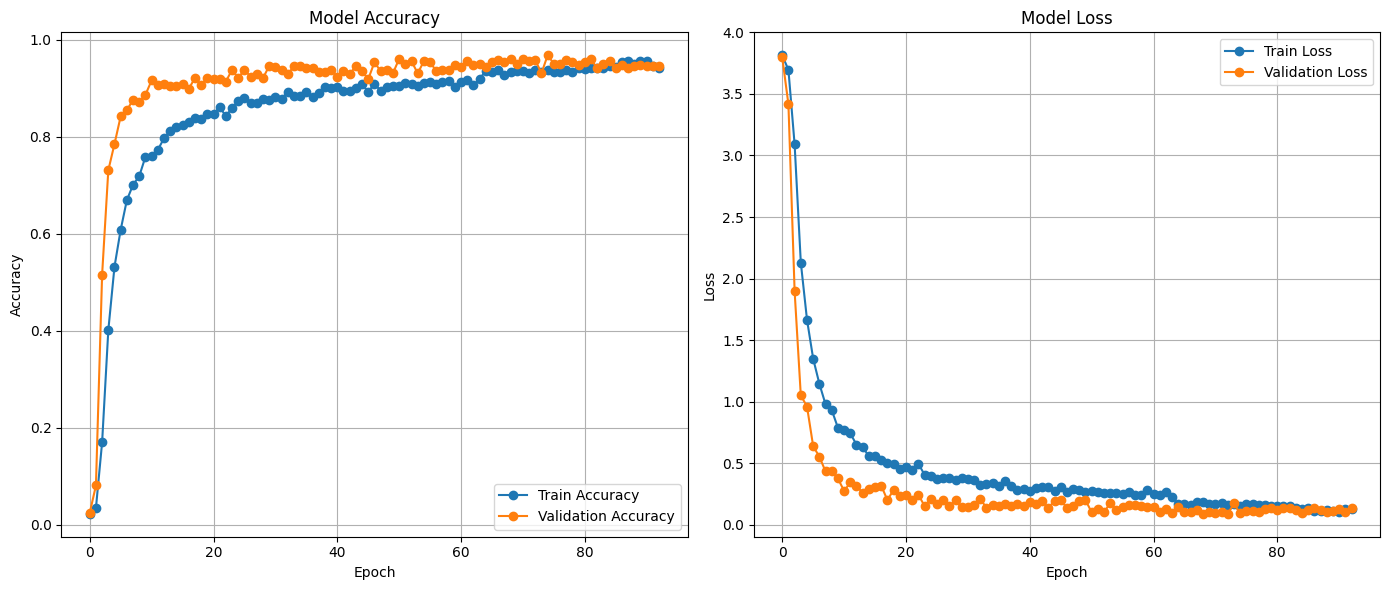

In [33]:
import matplotlib.pyplot as plt

# -----------------------------
# Plot Training Metrics
# -----------------------------
plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step


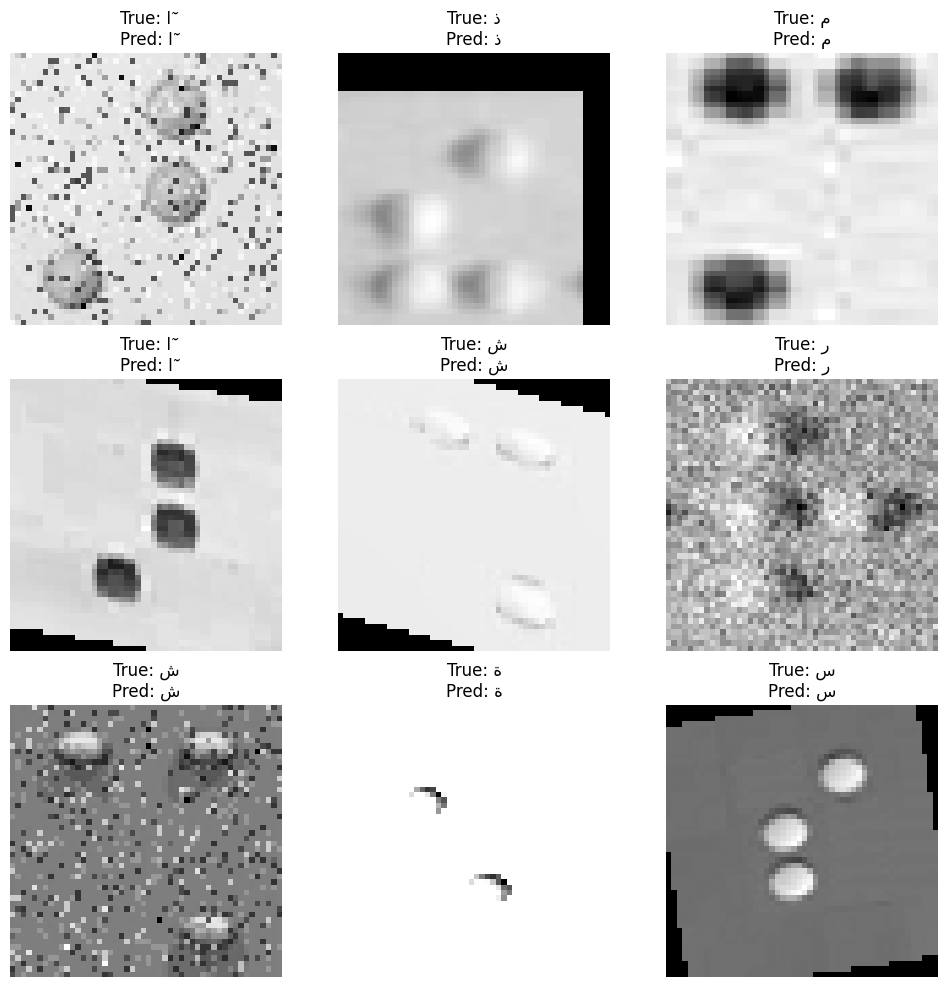

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Get the mapping: index → Arabic character
idx_to_char = {v: k for k, v in train_generator.class_indices.items()}

# Number of images to display
num_images = 9

# Get a batch of test images and labels
test_images, test_labels = next(test_generator)

# Predict
pred_probs = model.predict(test_images)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Plot images with predictions
plt.figure(figsize=(12, 12))
for i in range(num_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i].reshape(50, 50), cmap='gray')
    plt.axis('off')
    plt.title(f"True: {idx_to_char[true_classes[i]]}\nPred: {idx_to_char[pred_classes[i]]}")
plt.show()
